In [9]:
import numpy as np
import matplotlib.pyplot as plt

from astropy.io import fits

import treecorr

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Times New Roman"],  # You can change this font if you prefer
    "axes.labelsize": 14,  # Adjust as needed
    "axes.titlesize": 16,  # Adjust as needed
    "xtick.labelsize": 14,  # Adjust as needed
    "ytick.labelsize": 14,  # Adjust as needed
    "legend.fontsize": 12,  # Adjust as needed
    "figure.figsize": (10, 8),  # Adjust as needed
    "figure.dpi": 600  # Adjust as needed
})

root_dir = '/home/guerrini/sp_validation/cosmo_inference/data/'
dir_samples = '/home/guerrini/sp_validation/notebooks/cosmo_val/output/rho_tau_stats/'
versions = ['SP_v1.3_LFmask_8k', 'SP_v1.4-P1+3', 'SP_axel_v0.0']
colors = ["blue", "brown", "cyan"]
markers = ["x", "*", "o"]

Looking at version:  SP_v1.3_LFmask_8k
Looking at version:  SP_v1.4-P1+3
Looking at version:  SP_axel_v0.0


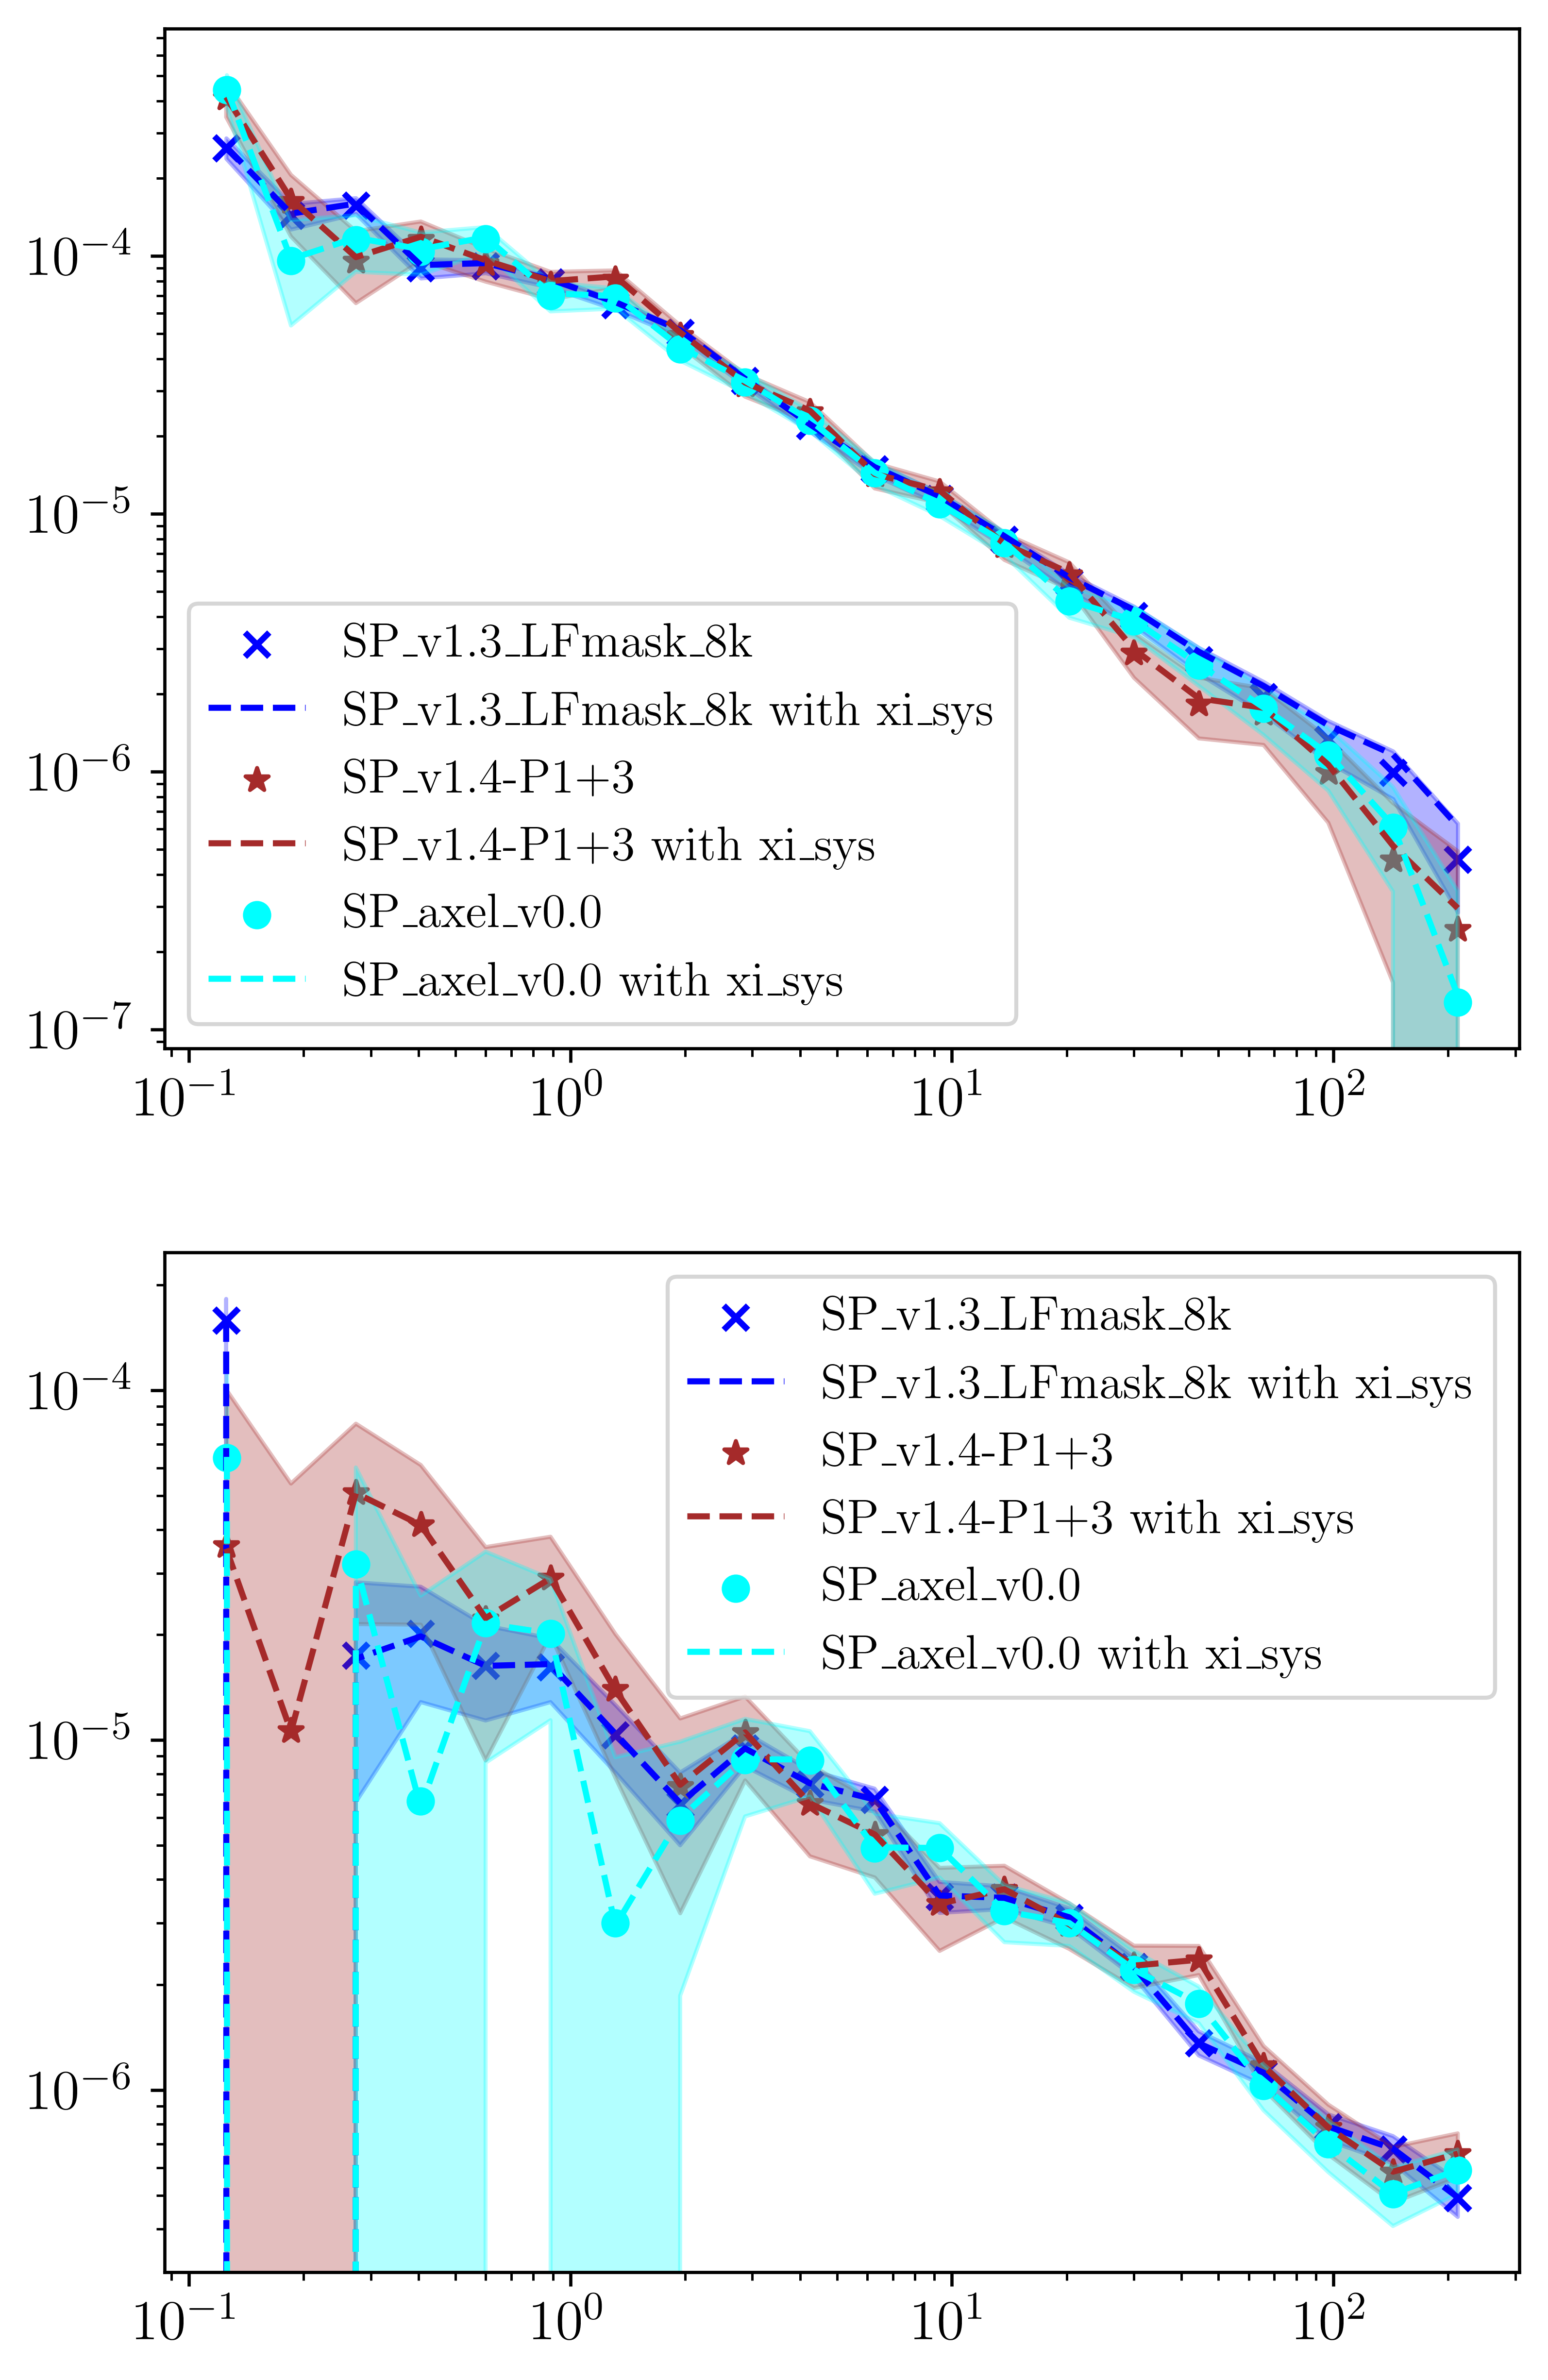

In [3]:
plt.figure(figsize=(6, 10))

for version, color, marker in zip(versions, colors, markers):

    print("Looking at version: ", version)

    #Load the data
    data = fits.open(root_dir + version + '/cosmosis_'+version+'.fits')
    cov_mat = data['COVMAT'].data
    xi_plus = data['XI_PLUS'].data
    xi_minus = data['XI_MINUS'].data
    rho_stats = data['RHO_STATS'].data

    samples_xi_sys = np.load(dir_samples + 'samples_' + version + '.npy')
    alpha, beta, eta = np.median(samples_xi_sys, axis=0)
    xi_sys_p = (
        alpha**2*rho_stats["rho_0_p"]
        + beta**2*rho_stats["rho_1_p"]
        + eta**2*rho_stats["rho_3_p"]
        + 2*alpha*beta*rho_stats["rho_2_p"]
        + 2*beta*eta*rho_stats["rho_4_p"]
        + 2*alpha*eta*rho_stats["rho_5_p"]
    )

    xi_sys_m = (
        alpha**2*rho_stats["rho_0_m"]
        + beta**2*rho_stats["rho_1_m"]
        + eta**2*rho_stats["rho_3_m"]
        + 2*alpha*beta*rho_stats["rho_2_m"]
        + 2*beta*eta*rho_stats["rho_4_m"]
        + 2*alpha*eta*rho_stats["rho_5_m"]
    )

    plt.subplot(211)
    #Plot correlation function with error bars
    plt.scatter(xi_plus['ANG'], xi_plus['VALUE'], color=color, marker=marker, label=version)
    plt.plot(xi_plus['ANG'], xi_plus['VALUE']+xi_sys_p, color=color, linestyle='--', label=version+' with xi_sys')
    plt.fill_between(xi_plus['ANG'], xi_plus['VALUE'] - np.sqrt(np.diag(cov_mat[0:20, 0:20])), xi_plus['VALUE'] + np.sqrt(np.diag(cov_mat[0:20, 0:20])), color=color, alpha=0.3)
    plt.xscale('log')
    plt.yscale('log')
    plt.legend()

    plt.subplot(212)
    plt.scatter(xi_minus['ANG'], xi_minus['VALUE'], color=color, marker=marker, label=version)
    plt.plot(xi_minus['ANG'], xi_minus['VALUE']+xi_sys_m, color=color, linestyle='--', label=version+' with xi_sys')
    plt.fill_between(xi_minus['ANG'], xi_minus['VALUE'] - np.sqrt(np.diag(cov_mat[20:40, 20:40])), xi_minus['VALUE'] + np.sqrt(np.diag(cov_mat[20:40, 20:40])), color=color, alpha=0.3)
    plt.xscale('log')
    plt.yscale('log')
    plt.legend()
plt.show()

### Compare covariance matrix

Build the galaxy catalog...
Starting to compute 2PCF with treecorr...
The following patch numbers have no objects: {263}
This may be a problem depending on your use case.


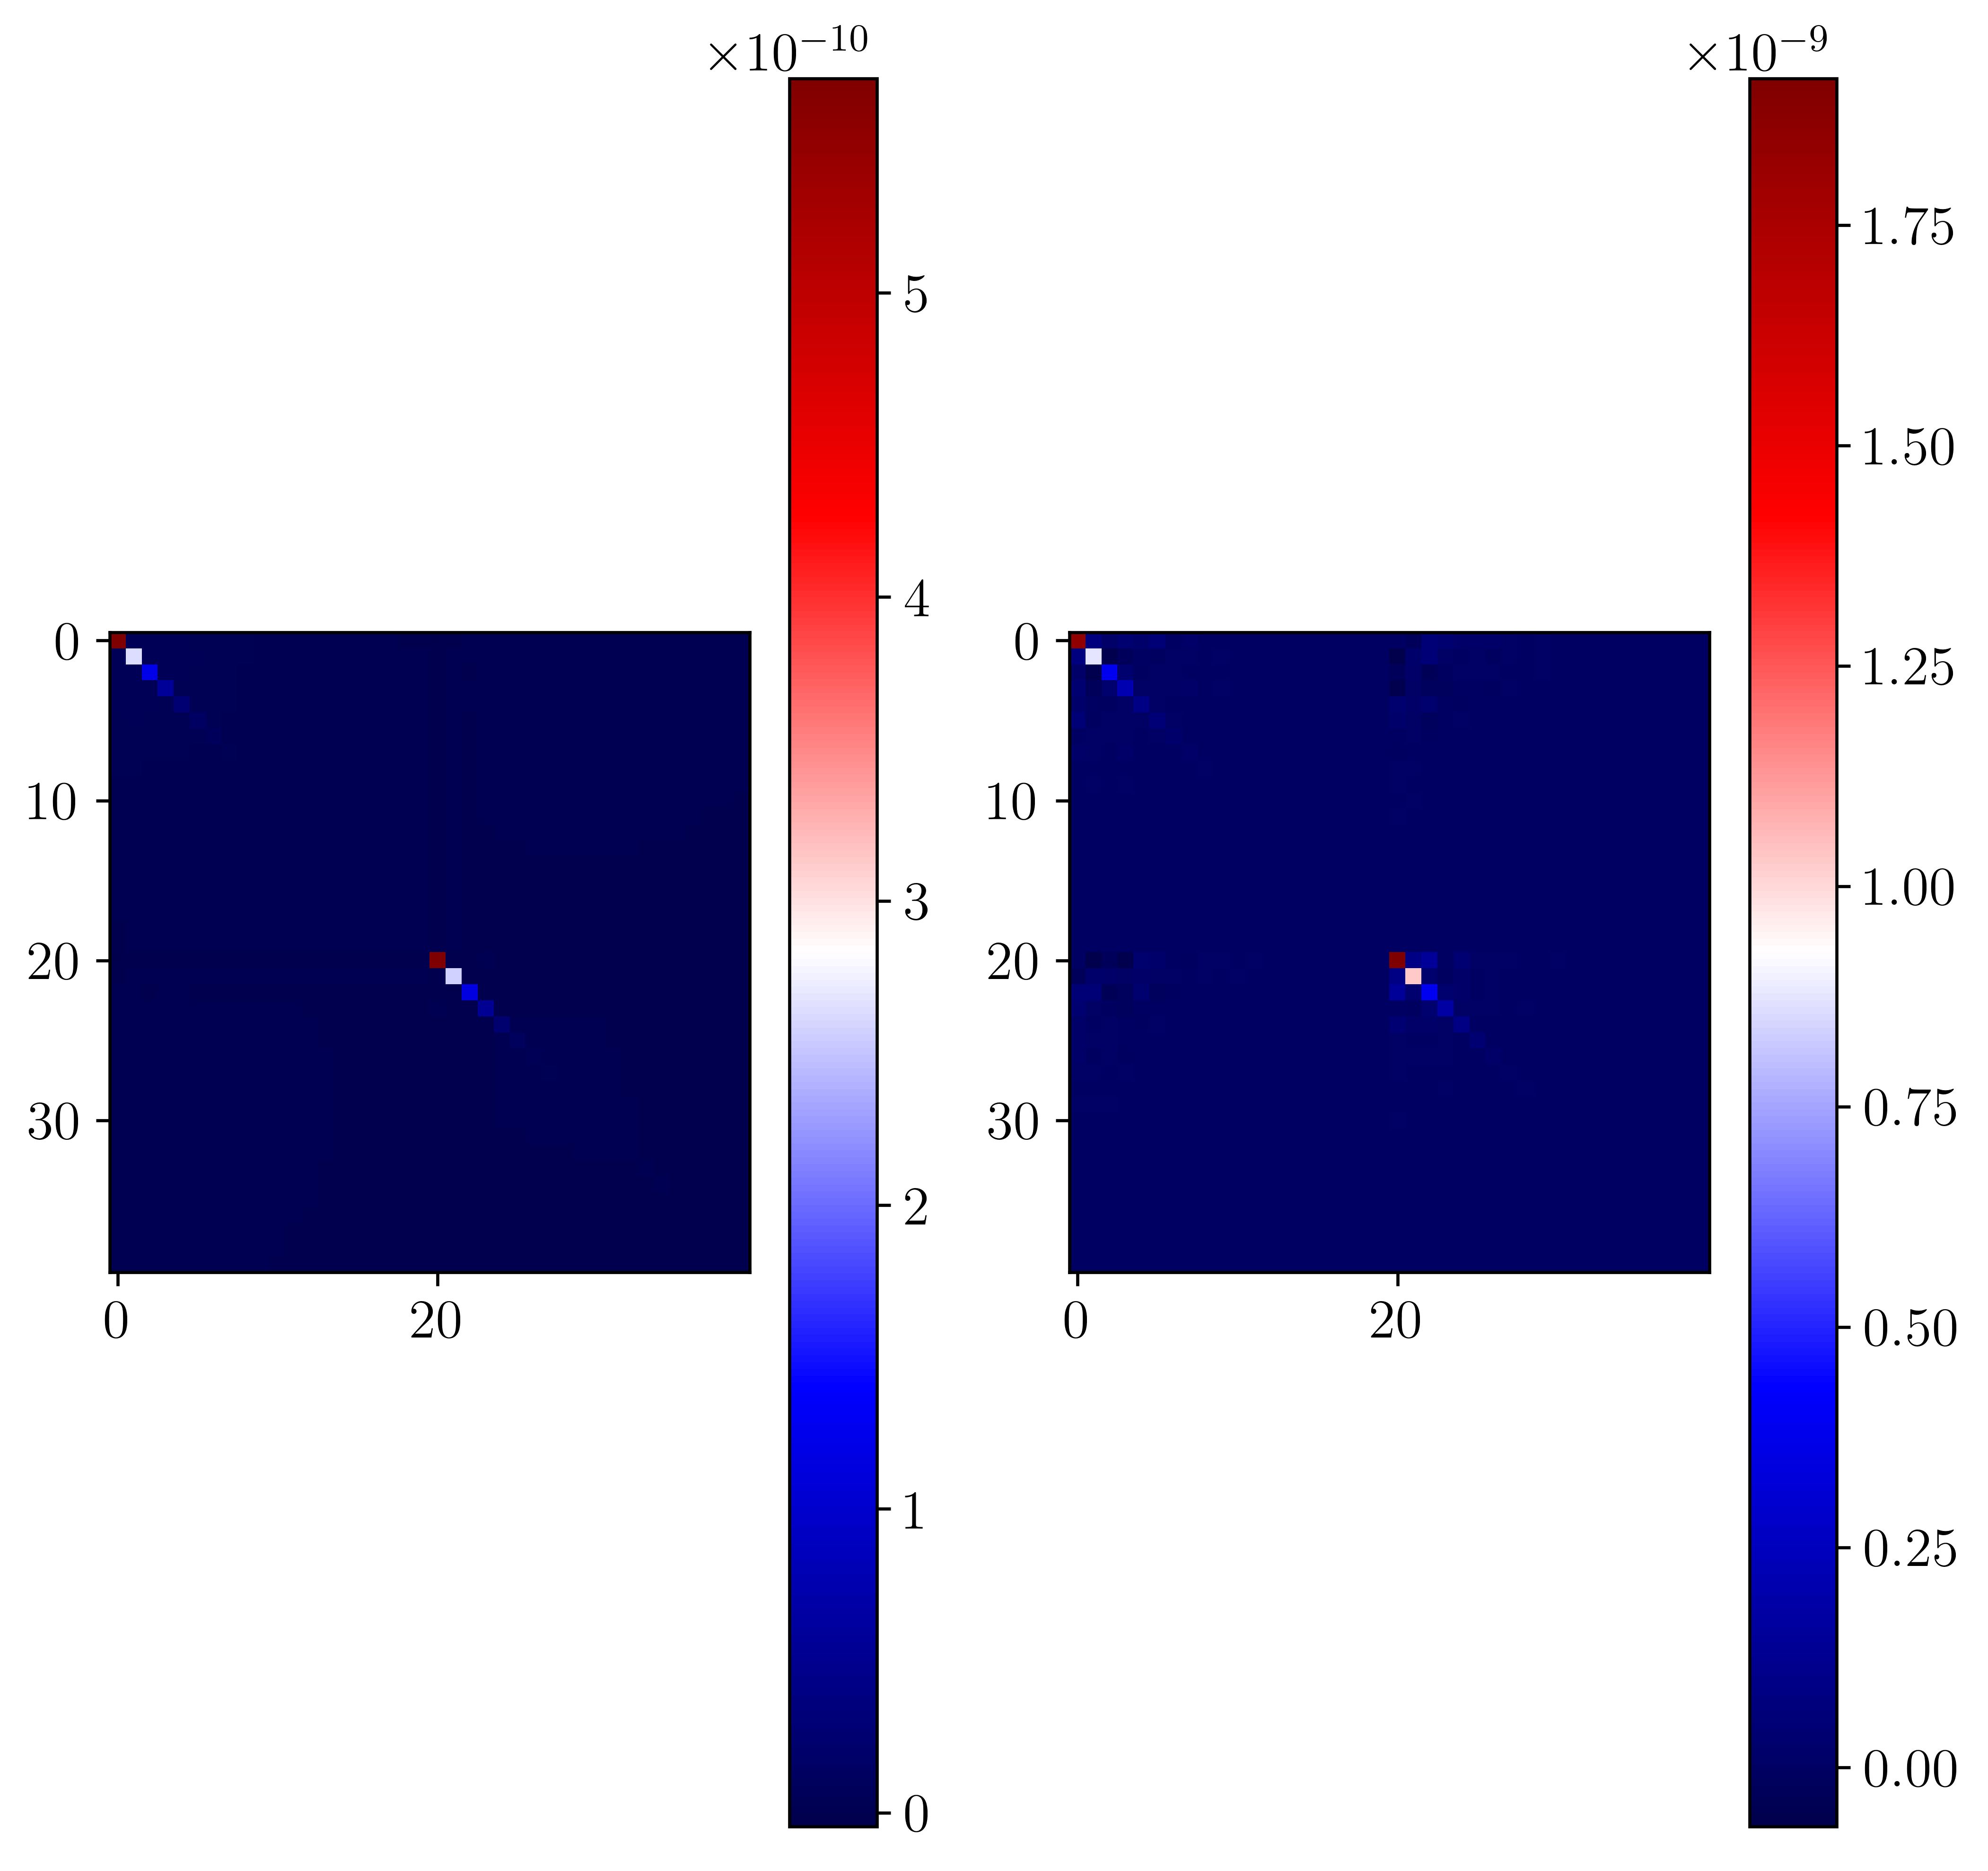

In [19]:
versions = ['SP_v1.3_LFmask_8k']
cat_root_dir = '/n17data/mkilbing/astro/data/CFIS/'
cat_path = [
    'v1.0/SP_LFmask/unions_shapepipe_2022_v1.3_mtheli8k.fits'
]

theta_min = 0.1
theta_max = 250
nbins = 20

sep_units = 'arcmin'
coord_units = 'degrees'

treecorr_config = {
    'ra_units': coord_units,
    'dec_units': coord_units,
    'min_sep': theta_min,
    'max_sep': theta_max,
    'sep_units': sep_units,
    'nbins': nbins,
}

for ver, cat in zip(versions, cat_path):
    data = fits.open(root_dir + ver + '/cosmosis_'+ver+'.fits')
    cov_mat_cosmocov = data['COVMAT'].data
    xi_plus = data['XI_PLUS'].data
    xi_minus = data['XI_MINUS'].data
    rho_stats = data['RHO_STATS'].data

    plt.figure(figsize=(8, 8))

    plt.subplot(121)
    plt.imshow(cov_mat_cosmocov, cmap='seismic')
    plt.colorbar()

    plt.subplot(122)

    cat_gal = fits.getdata(cat_root_dir + cat)
    print("Build the galaxy catalog...")
    cat_gal_tc = treecorr.Catalog(
        ra=cat_gal['RA'],
        dec=cat_gal['DEC'],
        ra_units=coord_units,
        dec_units=coord_units,
        g1 = cat_gal['e1'],
        g2 = cat_gal['e2'],
        w = cat_gal['w'],
        npatch=300
    )
    gg = treecorr.GGCorrelation(treecorr_config)
    print("Starting to compute 2PCF with treecorr...")
    gg.process(cat_gal_tc)
    cov_mat_jk = treecorr.estimate_multi_cov([gg], 'jackknife')
    plt.imshow(cov_mat_jk, cmap='seismic')
    plt.colorbar()
    plt.show()
    


In [24]:
corr_mat_cosmocov = np.corrcoef(cov_mat_cosmocov)
corr_mat_jk = np.corrcoef(cov_mat_jk)

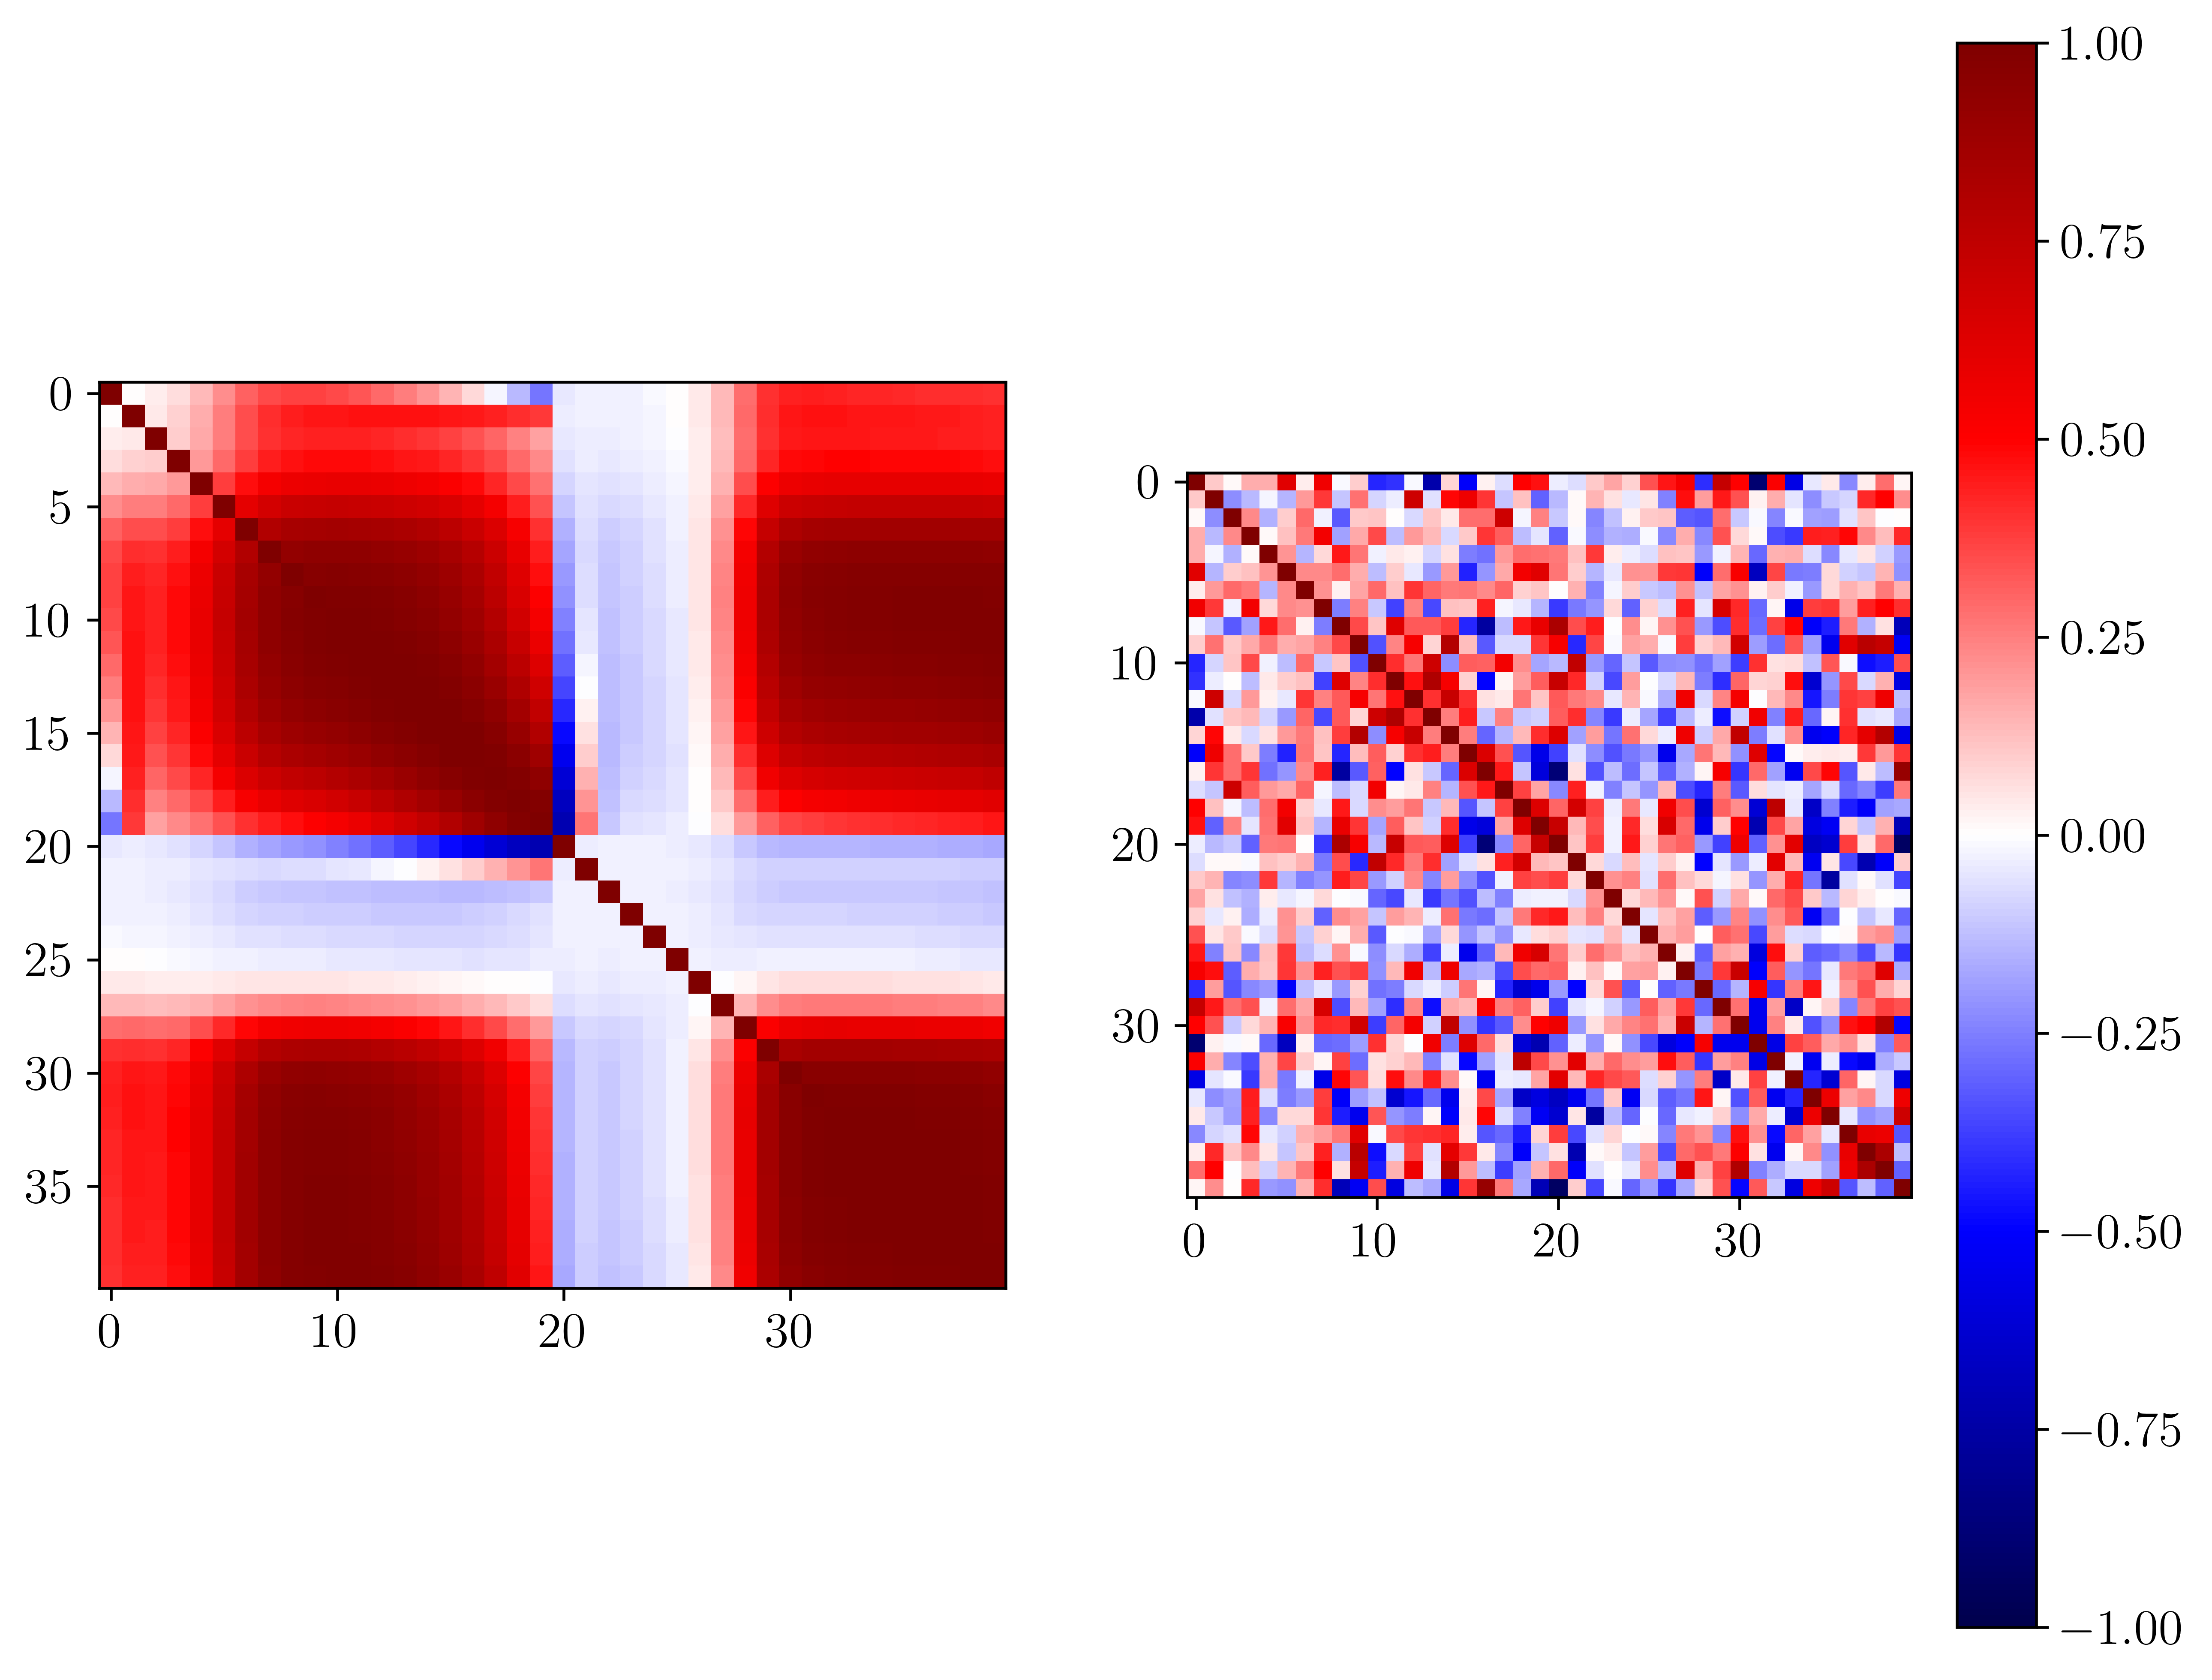

In [26]:
plt.figure()

plt.subplot(121)
plt.imshow(corr_mat_cosmocov, cmap='seismic', vmin=-1, vmax=1)  

plt.subplot(122)
plt.imshow(corr_mat_jk, cmap='seismic', vmin=-1, vmax=1)
plt.colorbar()
plt.show()

In [27]:
fig, axs = plt.subplots(20, 2, figsize=(15, 60))

for k in range(20):

    axs[k,0].plot(cov_mat_cosmocov[0:20, k], label='CosmoCov')
    axs[k,0].plot(cov_mat_jk[0:20, k], label='Jackknife')
    axs[k,0].set_xticks(np.arange(20))
    axs[k,0].set_yscale('log')

    axs[k,1].plot(corr_mat_cosmocov[0:20, k], label='CosmoCov')
    axs[k,1].plot(corr_mat_jk[0:20, k], label='Jackknife')
    axs[k,1].set_xticks(np.arange(20))
    axs[k, 1].text(15, 0.8, str(k+1))

axs[0, 0].legend()

plt.show()

In [23]:
cov_mat_jk

array([[ 1.84469615e-09,  8.03863677e-11,  1.47978072e-11, ...,
         1.18743246e-14,  1.15339169e-13,  1.08513458e-15],
       [ 8.03863677e-11,  8.72336066e-10, -5.54076538e-11, ...,
         2.84161560e-13,  2.32298987e-13,  1.18008648e-13],
       [ 1.47978072e-11, -5.54076538e-11,  3.95951621e-10, ...,
         1.23587233e-13,  3.81583001e-14, -6.74503514e-14],
       ...,
       [ 1.18743246e-14,  2.84161560e-13,  1.23587233e-13, ...,
         1.60663601e-14,  2.38689387e-15,  7.66897327e-16],
       [ 1.15339169e-13,  2.32298987e-13,  3.81583001e-14, ...,
         2.38689387e-15,  1.14649654e-14,  1.25667544e-15],
       [ 1.08513458e-15,  1.18008648e-13, -6.74503514e-14, ...,
         7.66897327e-16,  1.25667544e-15,  8.69439945e-15]])